# SyriaTel Customer Churn Prediction
## Phase 3 Classification Project

**Author:** Marcus Kaula  
**Date:** March 2026

---

## Table of Contents
1. [Business Understanding](#business)
2. [Data Understanding](#data)
3. [Data Preparation](#prep)
4. [Modeling](#modeling)
5. [Evaluation](#evaluation)
6. [Conclusions and Recommendations](#conclusions)

<a id='business'></a>
## 1. Business Understanding

### Stakeholder
SyriaTel, a telecommunications company

### Business Problem
Customer churn is a critical issue for telecommunications companies. When customers leave, the company loses:
- Recurring monthly revenue
- Customer lifetime value
- Market share to competitors

Acquiring new customers costs 5-25 times more than retaining existing ones. Therefore, **predicting which customers are likely to churn allows SyriaTel to:**
- Proactively engage at-risk customers with retention offers
- Allocate marketing resources more efficiently
- Understand key drivers of customer dissatisfaction

### Project Objective
Build and optimize logistic regression models to predict customer churn, focusing on:
1. Identifying customers at high risk of churning
2. Understanding which factors most influence churn
3. Providing actionable recommendations for retention strategies

### Success Metrics
Since the cost of losing a customer is high, we'll prioritize **recall** (identifying as many churners as possible) while maintaining reasonable precision to avoid wasting retention resources on customers who wouldn't churn anyway.

In [79]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, mean_squared_error, make_scorer
from imblearn.over_sampling import SMOTE

<a id='data'></a>
## 2. Data Understanding

In [80]:
# Load the dataset
df = pd.read_csv('data/bigml_59c28831336c6604c800002a.csv')
df.head()

,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,...,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [81]:
df.tail()

,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,...,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
3328,AZ,192,415,414-4276,no,yes,36,156.2,77,26.55,...,126,18.32,279.1,83,12.56,9.9,6,2.67,2,False
3329,WV,68,415,370-3271,no,no,0,231.1,57,39.29,...,55,13.04,191.3,123,8.61,9.6,4,2.59,3,False
3330,RI,28,510,328-8230,no,no,0,180.8,109,30.74,...,58,24.55,191.9,91,8.64,14.1,6,3.81,2,False
3331,CT,184,510,364-6381,yes,no,0,213.8,105,36.35,...,84,13.57,139.2,137,6.26,5.0,10,1.35,2,False
3332,TN,74,415,400-4344,no,yes,25,234.4,113,39.85,...,82,22.60,241.4,77,10.86,13.7,4,3.70,0,False


In [82]:
# Display shape of the dataset
print("Dataset Shape:", df.shape)

Dataset Shape: (3333, 21)


In [83]:
# Dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   state                   3333 non-null   object 
 1   account length          3333 non-null   int64  
 2   area code               3333 non-null   int64  
 3   phone number            3333 non-null   object 
 4   international plan      3333 non-null   object 
 5   voice mail plan         3333 non-null   object 
 6   number vmail messages   3333 non-null   int64  
 7   total day minutes       3333 non-null   float64
 8   total day calls         3333 non-null   int64  
 9   total day charge        3333 non-null   float64
 10  total eve minutes       3333 non-null   float64
 11  total eve calls         3333 non-null   int64  
 12  total eve charge        3333 non-null   float64
 13  total night minutes     3333 non-null   float64
 14  total night calls       3333 non-null   

In [84]:
# Statistical summary
df.describe()

,account length,area code,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls
count,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000
mean,101.064806,437.182418,8.099010,179.775098,100.435644,30.562307,200.980348,100.114311,17.083540,200.872037,100.107711,9.039325,10.237294,4.479448,2.764581,1.562856
std,39.822106,42.371290,13.688365,54.467389,20.069084,9.259435,50.713844,19.922625,4.310668,50.573847,19.568609,2.275873,2.791840,2.461214,0.753773,1.315491
min,1.000000,408.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,23.200000,33.000000,1.040000,0.000000,0.000000,0.000000,0.000000
25%,74.000000,408.000000,0.000000,143.700000,87.000000,24.430000,166.600000,87.000000,14.160000,167.000000,87.000000,7.520000,8.500000,3.000000,2.300000,1.000000
50%,101.000000,415.000000,0.000000,179.400000,101.000000,30.500000,201.400000,100.000000,17.120000,201.200000,100.000000,9.050000,10.300000,4.000000,2.780000,1.000000
75%,127.000000,510.000000,20.000000,216.400000,114.000000,36.790000,235.300000,114.000000,20.000000,235.300000,113.000000,10.590000,12.100000,6.000000,3.270000,2.000000
max,243.000000,510.000000,51.000000,350.800000,165.000000,59.640000,363.700000,170.000000,30.910000,395.000000,175.000000,17.770000,20.000000,20.000000,5.400000,9.000000


In [85]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
state                     0
account length            0
area code                 0
phone number              0
international plan        0
voice mail plan           0
number vmail messages     0
total day minutes         0
total day calls           0
total day charge          0
total eve minutes         0
total eve calls           0
total eve charge          0
total night minutes       0
total night calls         0
total night charge        0
total intl minutes        0
total intl calls          0
total intl charge         0
customer service calls    0
churn                     0
dtype: int64


In [86]:
print("\nPercentage of Missing Values:")
print((df.isnull().sum() / len(df) * 100).round(2))


Percentage of Missing Values:
state                     0.0
account length            0.0
area code                 0.0
phone number              0.0
international plan        0.0
voice mail plan           0.0
number vmail messages     0.0
total day minutes         0.0
total day calls           0.0
total day charge          0.0
total eve minutes         0.0
total eve calls           0.0
total eve charge          0.0
total night minutes       0.0
total night calls         0.0
total night charge        0.0
total intl minutes        0.0
total intl calls          0.0
total intl charge         0.0
customer service calls    0.0
churn                     0.0
dtype: float64


In [87]:
# Check for duplicates
print(f"Number of duplicate rows: {df.duplicated().sum()}")

Number of duplicate rows: 0


### Target Variable Analysis

In [88]:
# Check target variable distribution
print("Churn Distribution:")
print(df['churn'].value_counts())
print("\nChurn Percentage:")
print(df['churn'].value_counts(normalize=True) * 100)

Churn Distribution:
False    2850
True      483
Name: churn, dtype: int64

Churn Percentage:
False    85.508551
True     14.491449
Name: churn, dtype: float64


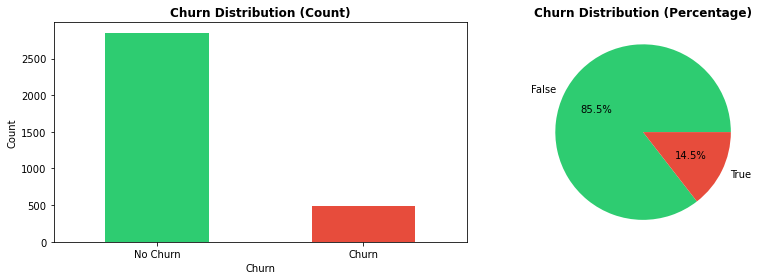

In [89]:
# Visualize churn distribution
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

df['churn'].value_counts().plot(kind='bar', ax=ax[0], color=['#2ecc71', '#e74c3c'])
ax[0].set_title('Churn Distribution (Count)', fontsize=12, fontweight='bold')
ax[0].set_xlabel('Churn')
ax[0].set_ylabel('Count')
ax[0].set_xticklabels(['No Churn', 'Churn'], rotation=0)

df['churn'].value_counts(normalize=True).plot(kind='pie', ax=ax[1], autopct='%1.1f%%',
                                              colors=['#2ecc71', '#e74c3c'])
ax[1].set_title('Churn Distribution (Percentage)', fontsize=12, fontweight='bold')
ax[1].set_ylabel('')

plt.tight_layout()
# plt.savefig('churn_Distribution', dpi=150, bbox_inches = 'tight')
plt.show()

In [90]:
# Calculate class imbalance ratio
churn_counts = df['churn'].value_counts()
print("Churn Counts:")
print(churn_counts)
imbalance_ratio = churn_counts[False] / churn_counts[True]
print(f"\nClass Imbalance Ratio: {imbalance_ratio:.2f}:1")
print("This indicates significant class imbalance - we'll address this with SMOTE.")

Churn Counts:
False    2850
True      483
Name: churn, dtype: int64

Class Imbalance Ratio: 5.90:1
This indicates significant class imbalance - we'll address this with SMOTE.


### Exploratory Data Analysis

In [91]:
# Separate numerical and categorical features
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()

# Remove target from lists
if 'churn' in numerical_cols:
    numerical_cols.remove('churn')
if 'churn' in categorical_cols:
    categorical_cols.remove('churn')

print(f"Numerical features ({len(numerical_cols)}): {numerical_cols}")
print(f"\nCategorical features ({len(categorical_cols)}): {categorical_cols}")

Numerical features (16): ['account length', 'area code', 'number vmail messages', 'total day minutes', 'total day calls', 'total day charge', 'total eve minutes', 'total eve calls', 'total eve charge', 'total night minutes', 'total night calls', 'total night charge', 'total intl minutes', 'total intl calls', 'total intl charge', 'customer service calls']

Categorical features (4): ['state', 'phone number', 'international plan', 'voice mail plan']


In [92]:
# Analyze numerical features by churn status
print("Numerical Features - Mean by Churn Status:")
df.groupby('churn')[numerical_cols].mean()

Numerical Features - Mean by Churn Status:


,account length,area code,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls
churn,,,,,,,,,,,,,,,,
False,100.793684,437.074737,8.604561,175.175754,100.283158,29.780421,199.043298,100.038596,16.918909,200.133193,100.058246,9.006074,10.158877,4.532982,2.743404,1.449825
True,102.664596,437.817805,5.115942,206.914079,101.335404,35.175921,212.410145,100.561077,18.054969,205.231677,100.399586,9.235528,10.700000,4.163561,2.889545,2.229814


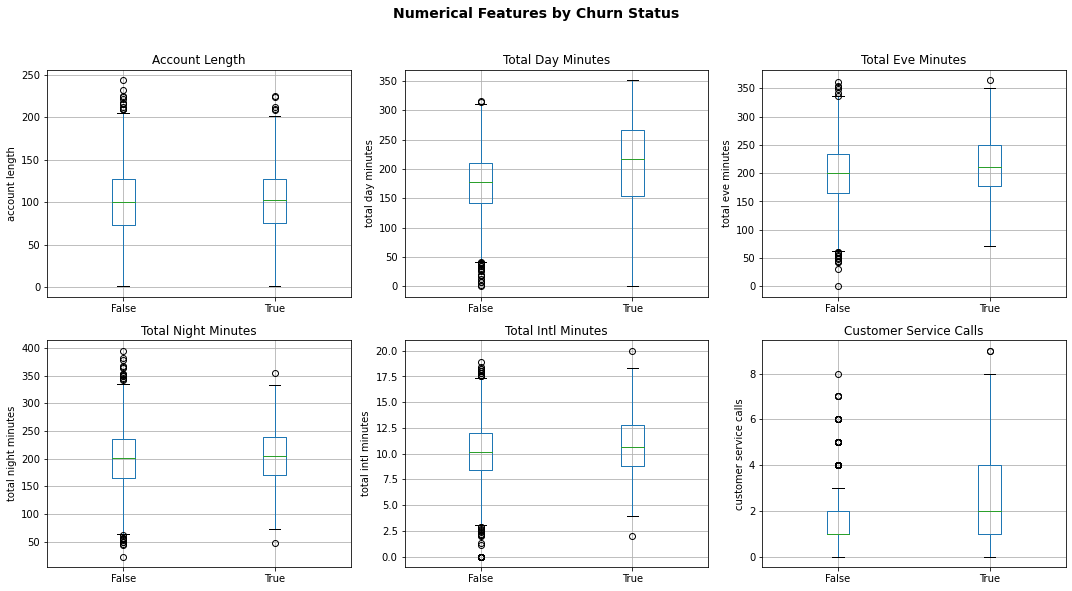

In [93]:
# Visualize key numerical features
key_features = ['account length', 'total day minutes', 'total eve minutes', 
                'total night minutes', 'total intl minutes', 'customer service calls']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for idx, col in enumerate(key_features):
    df.boxplot(column=col, by='churn', ax=axes[idx])
    axes[idx].set_title(f'{col.title()}')
    axes[idx].set_xlabel('')
    axes[idx].set_ylabel(col)
    
plt.suptitle('Numerical Features by Churn Status', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
# plt.savefig('Numerical_Features_By_Churn_Status', dpi=150, bbox_inches = 'tight')
plt.show()

In [94]:
# Analyze categorical features
for col in categorical_cols:
    if col != 'phone number':  # Skip phone number as it's unique identifier
        print(f"\n{col.upper()}:")
        churn_rate = df.groupby(col)['churn'].agg(['sum', 'count', 'mean'])
        churn_rate.columns = ['Churned', 'Total', 'Churn Rate']
        churn_rate['Churn Rate'] = (churn_rate['Churn Rate'] * 100).round(2)
        print(churn_rate)


STATE:
       Churned  Total  Churn Rate
state                            
AK           3     52        5.77
AL           8     80       10.00
AR          11     55       20.00
AZ           4     64        6.25
CA           9     34       26.47
CO           9     66       13.64
CT          12     74       16.22
DC           5     54        9.26
DE           9     61       14.75
FL           8     63       12.70
GA           8     54       14.81
HI           3     53        5.66
IA           3     44        6.82
ID           9     73       12.33
IL           5     58        8.62
IN           9     71       12.68
KS          13     70       18.57
KY           8     59       13.56
LA           4     51        7.84
MA          11     65       16.92
MD          17     70       24.29
ME          13     62       20.97
MI          16     73       21.92
MN          15     84       17.86
MO           7     63       11.11
MS          14     65       21.54
MT          14     68       20.59
NC    

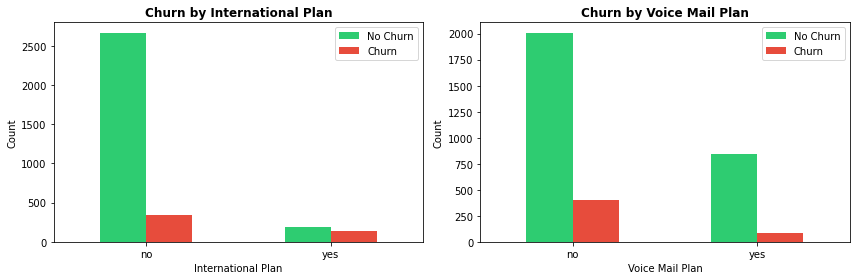

In [95]:
# Visualize categorical features
cat_features = ['international plan', 'voice mail plan']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for index, column in enumerate(cat_features):
    churn_by_cat = df.groupby([column, 'churn']).size().unstack()
    churn_by_cat.plot(kind='bar', ax=axes[index], color=['#2ecc71', '#e74c3c'])
    axes[index].set_title(f'Churn by {column.title()}', fontweight='bold')
    axes[index].set_xlabel(column.title())
    axes[index].set_ylabel('Count')
    axes[index].legend(['No Churn', 'Churn'])
    axes[index].set_xticklabels(axes[index].get_xticklabels(), rotation=0)

plt.tight_layout()
# plt.savefig('churn_by_categorical_features', dpi=150, bbox_inches = 'tight')
plt.show()

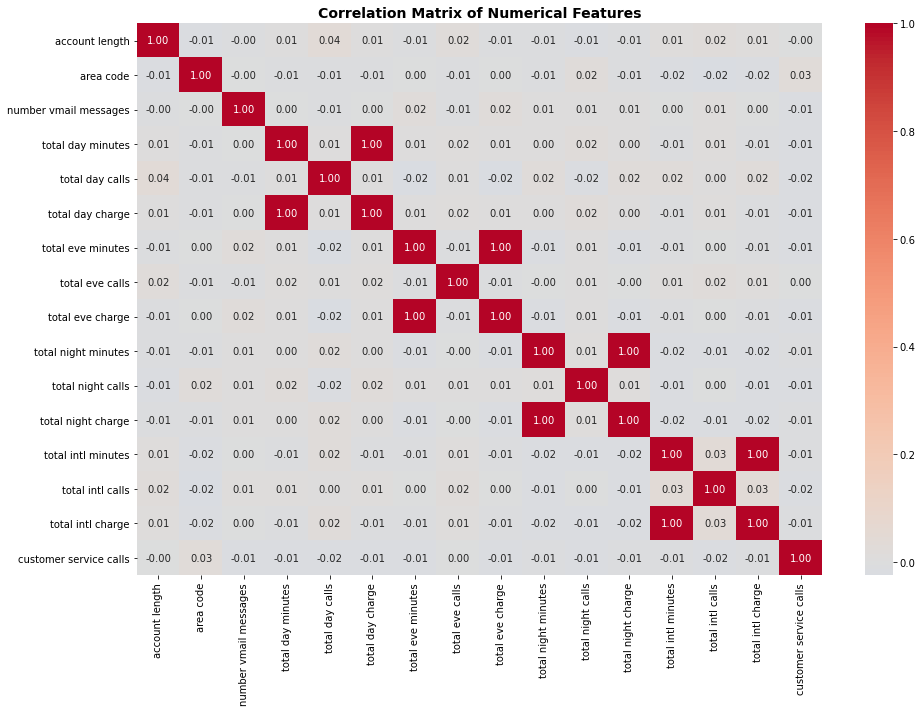

In [96]:
# Correlation analysis
plt.figure(figsize=(14, 10))
correlation = df[numerical_cols].corr()
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
# plt.savefig('correlation_matrix', dpi=150, bbox_inches = 'tight')
plt.show()

### Key Insights from EDA

Based on the exploratory analysis:

1. **Class Imbalance**: The dataset shows significant class imbalance (typically 85% non-churn, 15% churn)
2. **Important Patterns**:
   - Customers with international plans show higher churn rates
   - Higher customer service calls correlate with increased churn
   - Total day charges and minutes show differences between churners and non-churners
3. **Multicollinearity**: Strong correlations exist between minutes and charges features
4. **Data Quality**: No missing values detected

<a id='prep'></a>
## 3. Data Preparation

In [97]:
# Create a copy for preprocessing
df_model = df.copy()

# Drop unnecessary columns
columns_to_drop = ['phone number']  # Unique identifier, not predictive
df_model = df_model.drop(columns=columns_to_drop)

### Feature Engineering

In [98]:
# Create new features

# 1. Total usage features
df_model['total_minutes'] = (df_model['total day minutes'] + 
                             df_model['total eve minutes'] + 
                             df_model['total night minutes'] + 
                             df_model['total intl minutes'])

df_model['total_calls'] = (df_model['total day calls'] + 
                           df_model['total eve calls'] + 
                           df_model['total night calls'] + 
                           df_model['total intl calls'])

df_model['total_charge'] = (df_model['total day charge'] + 
                            df_model['total eve charge'] + 
                            df_model['total night charge'] + 
                            df_model['total intl charge'])

# 2. Average charge per call
df_model['avg_charge_per_call'] = df_model['total_charge'] / (df_model['total_calls'] + 1)  # +1 to avoid division by zero

# 3. Customer service calls indicator (high service calls)
df_model['high_service_calls'] = (df_model['customer service calls'] >= 4).astype(int)

# 4. Day usage ratio
df_model['day_usage_ratio'] = df_model['total day minutes'] / (df_model['total_minutes'] + 1)

# 5. International usage indicator
df_model['intl_user'] = (df_model['total intl calls'] > 0).astype(int)

print("New features created:")
print(['total_minutes', 'total_calls', 'total_charge', 'avg_charge_per_call', 
       'high_service_calls', 'day_usage_ratio', 'intl_user'])
df_model.head()

New features created:
['total_minutes', 'total_calls', 'total_charge', 'avg_charge_per_call', 'high_service_calls', 'day_usage_ratio', 'intl_user']


,state,account length,area code,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,...,total intl charge,customer service calls,churn,total_minutes,total_calls,total_charge,avg_charge_per_call,high_service_calls,day_usage_ratio,intl_user
0,KS,128,415,no,yes,25,265.1,110,45.07,197.4,...,2.70,1,False,717.2,303,75.56,0.248553,0,0.369117,1
1,OH,107,415,no,yes,26,161.6,123,27.47,195.5,...,3.70,1,False,625.2,332,59.24,0.177898,0,0.258065,1
2,NJ,137,415,no,no,0,243.4,114,41.38,121.2,...,3.29,0,False,539.4,333,62.29,0.186497,0,0.450407,1
3,OH,84,408,yes,no,0,299.4,71,50.90,61.9,...,1.78,2,False,564.8,255,66.80,0.260937,0,0.529162,1
4,OK,75,415,yes,no,0,166.7,113,28.34,148.3,...,2.73,3,False,512.0,359,52.09,0.144694,0,0.324951,1


### Encoding Categorical Variables

In [99]:
# Encode binary categorical variables
binary_encodings = {
    'international plan': {'no': 0, 'yes': 1},
    'voice mail plan': {'no': 0, 'yes': 1}
}

for col, mapping in binary_encodings.items():
    df_model[col] = df_model[col].map(mapping)

# Drop state as it has many categories and may cause overfitting
df_model = df_model.drop('state', axis=1)

# Encode area code as categorical
df_model = pd.get_dummies(df_model, columns=['area code'], prefix='area', drop_first=True)

print("Encoding complete. New shape:", df_model.shape)
df_model.head()

Encoding complete. New shape: (3333, 27)


,account length,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,...,churn,total_minutes,total_calls,total_charge,avg_charge_per_call,high_service_calls,day_usage_ratio,intl_user,area_415,area_510
0,128,0,1,25,265.1,110,45.07,197.4,99,16.78,...,False,717.2,303,75.56,0.248553,0,0.369117,1,1,0
1,107,0,1,26,161.6,123,27.47,195.5,103,16.62,...,False,625.2,332,59.24,0.177898,0,0.258065,1,1,0
2,137,0,0,0,243.4,114,41.38,121.2,110,10.30,...,False,539.4,333,62.29,0.186497,0,0.450407,1,1,0
3,84,1,0,0,299.4,71,50.90,61.9,88,5.26,...,False,564.8,255,66.80,0.260937,0,0.529162,1,0,0
4,75,1,0,0,166.7,113,28.34,148.3,122,12.61,...,False,512.0,359,52.09,0.144694,0,0.324951,1,1,0


### Train-Test Split

In [100]:
# Separate features and target
X = df_model.drop('churn', axis=1)
y = df_model['churn'].astype(int)  # Convert boolean to int

# Split the data (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                      random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set size: {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nFeatures: {X_train.shape[1]}")
print(f"\nTraining set churn rate: {y_train.sum()/len(y_train)*100:.2f}%")
print(f"Test set churn rate: {y_test.sum()/len(y_test)*100:.2f}%")

Training set size: 2666 (80.0%)
Test set size: 667 (20.0%)

Features: 26

Training set churn rate: 14.48%
Test set churn rate: 14.54%


### Feature Scaling

In [101]:
# Initialize and fit scaler on training data only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # Transform test data using training parameters

# Convert back to DataFrames for easier manipulation
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Features scaled using StandardScaler")
print("\nScaled training data sample:")
X_train_scaled.head()

Features scaled using StandardScaler

Scaled training data sample:


,account length,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,...,customer service calls,total_minutes,total_calls,total_charge,avg_charge_per_call,high_service_calls,day_usage_ratio,intl_user,area_415,area_510
3286,0.125737,-0.325216,1.625447,1.606822,0.743376,0.225611,0.743639,0.426270,0.445403,0.426916,...,-1.200212,0.253991,0.381308,0.726949,0.326332,-0.299161,0.730834,0.075221,0.997752,-0.570131
86,-0.175309,-0.325216,-0.615216,-0.588791,-0.401294,0.225611,-0.401678,-0.904961,0.045354,-0.903861,...,1.875007,-0.904181,-0.288962,-0.833101,-0.614967,3.342681,0.089755,0.075221,-1.002253,-0.570131
1349,-0.752313,-0.325216,1.625447,1.021325,-0.704945,0.325566,-0.704787,-0.746481,0.245378,-0.745379,...,0.337397,-0.685552,0.264739,-0.967340,-0.974864,-0.299161,-0.461696,0.075221,-1.002253,1.753982
1649,0.727828,-0.325216,-0.615216,-0.588791,-2.048368,-0.723960,-2.048208,-0.146239,0.495409,-0.146413,...,-1.200212,-1.654245,0.993294,-1.995228,-2.023042,-0.299161,-1.923794,0.075221,-1.002253,-0.570131
3000,-0.350919,-0.325216,-0.615216,-0.588791,0.800425,0.425520,0.799931,-1.449735,-0.704736,-1.449223,...,1.106202,0.710308,-0.667811,0.606134,0.868386,-0.299161,0.503294,0.075221,-1.002253,1.753982


### Handling Class Imbalance with SMOTE

In [102]:
# Apply SMOTE to training data only
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print("Class distribution before SMOTE:")
print(pd.Series(y_train).value_counts())
print("\nClass distribution after SMOTE:")
print(pd.Series(y_train_resampled).value_counts())

Class distribution before SMOTE:
0    2280
1     386
Name: churn, dtype: int64

Class distribution after SMOTE:
0    2280
1    2280
Name: churn, dtype: int64


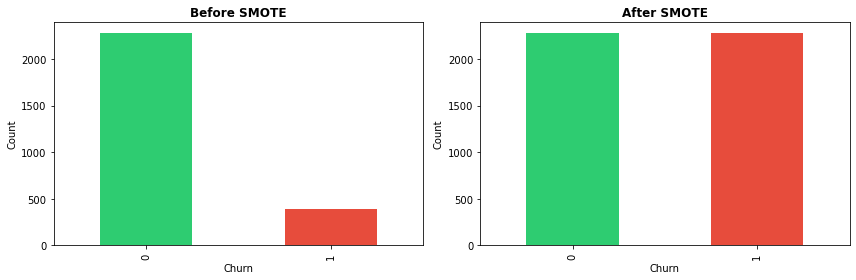

In [103]:
# Visualize the effect
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

pd.Series(y_train).value_counts().plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Before SMOTE', fontweight='bold')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Count')

pd.Series(y_train_resampled).value_counts().plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'])
axes[1].set_title('After SMOTE', fontweight='bold')
axes[1].set_xlabel('Churn')
axes[1].set_ylabel('Count')

plt.tight_layout()
# plt.savefig('SMOTE_effect', dpi=150, bbox_inches = 'tight')
plt.show()

<a id='modeling'></a>
## 4. Modeling

We will build multiple logistic regression models with increasing complexity:

1. **Baseline Model**: Simple logistic regression with default parameters
2. **Ridge**: Adding regularization to reduce overfitting
3. **Lasso**: For feature selection
4. **Tuned Model**: Using GridSearchCV to find optimal hyperparameters
5. **Feature-Selected Model**: Using best features from L1 regularization

In [104]:
# Function to evaluate models
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    """
    Evaluate a model and print comprehensive metrics
    """
    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    y_test_proba = model.predict_proba(X_test)[:, 1]
    
    # Calculate metrics
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    precision = precision_score(y_test, y_test_pred)
    recall = recall_score(y_test, y_test_pred)
    f1 = f1_score(y_test, y_test_pred)
    roc_auc = roc_auc_score(y_test, y_test_proba)
    mse = mean_squared_error(y_test, y_test_proba)
    
    # Print results
    print(f"\n{'='*60}")
    print(f"{model_name}")
    print(f"{'='*60}")
    print(f"Train Accuracy: {train_accuracy:.4f}")
    print(f"Test Accuracy:  {test_accuracy:.4f}")
    print(f"Precision:      {precision:.4f}")
    print(f"Recall:         {recall:.4f}")
    print(f"F1-Score:       {f1:.4f}")
    print(f"ROC-AUC:        {roc_auc:.4f}")
    print(f"MSE:            {mse:.4f}")

    
    # Classification report
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_test_pred, target_names=['No Churn', 'Churn']))
    
    return {
        'model_name': model_name,
        'train_accuracy': train_accuracy,
        'test_accuracy': test_accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc,
        'y_test_proba': y_test_proba,
        'mse': mse

    }

# Store results for comparison
model_results = []

### Model 1: Baseline Logistic Regression

In [105]:
# Train baseline model with default parameters
baseline_model = LogisticRegression(max_iter=1000, random_state=42)
baseline_model.fit(X_train_scaled, y_train)

# Evaluate
baseline_results = evaluate_model(baseline_model, X_train_scaled, y_train, 
                                  X_test_scaled, y_test, "Baseline Logistic Regression")
model_results.append(baseline_results)


Baseline Logistic Regression
Train Accuracy: 0.8612
Test Accuracy:  0.8591
Precision:      0.5306
Recall:         0.2680
F1-Score:       0.3562
ROC-AUC:        0.8631
MSE:            0.0930

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.89      0.96      0.92       570
       Churn       0.53      0.27      0.36        97

    accuracy                           0.86       667
   macro avg       0.71      0.61      0.64       667
weighted avg       0.83      0.86      0.84       667



### Model 2: Logistic Regression with SMOTE

In [106]:
# Train model on SMOTE-resampled data
smote_model = LogisticRegression(max_iter=1000, random_state=42)
smote_model.fit(X_train_resampled, y_train_resampled)

# Evaluate (note: we evaluate on original test set, not resampled)
smote_results = evaluate_model(smote_model, X_train_resampled, y_train_resampled,
                               X_test_scaled, y_test, "Logistic Regression with SMOTE")
model_results.append(smote_results)


Logistic Regression with SMOTE
Train Accuracy: 0.8669
Test Accuracy:  0.8456
Precision:      0.4813
Recall:         0.7938
F1-Score:       0.5992
ROC-AUC:        0.8585
MSE:            0.1329

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.96      0.85      0.90       570
       Churn       0.48      0.79      0.60        97

    accuracy                           0.85       667
   macro avg       0.72      0.82      0.75       667
weighted avg       0.89      0.85      0.86       667



### Model 3: L2 Regularization (Ridge)

In [107]:
# Train with L2 regularization
l2_model = LogisticRegression(penalty='l2', C=0.1, max_iter=1000, random_state=42)
l2_model.fit(X_train_resampled, y_train_resampled)

# Evaluate
l2_results = evaluate_model(l2_model, X_train_resampled, y_train_resampled,
                            X_test_scaled, y_test, "L2 Regularization-Ridge (C=0.1)")
model_results.append(l2_results)


L2 Regularization-Ridge (C=0.1)
Train Accuracy: 0.8660
Test Accuracy:  0.8501
Precision:      0.4907
Recall:         0.8144
F1-Score:       0.6124
ROC-AUC:        0.8602
MSE:            0.1344

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.96      0.86      0.91       570
       Churn       0.49      0.81      0.61        97

    accuracy                           0.85       667
   macro avg       0.73      0.84      0.76       667
weighted avg       0.90      0.85      0.86       667



### Model 4: L1 Regularization (Lasso) for Feature Selection

In [108]:
# Train with L1 regularization
l1_model = LogisticRegression(penalty='l1', C=0.1, solver='liblinear', max_iter=1000, random_state=42)
l1_model.fit(X_train_resampled, y_train_resampled)

# Evaluate
l1_results = evaluate_model(l1_model, X_train_resampled, y_train_resampled,
                            X_test_scaled, y_test, "L1 Regularization-Lasso (C=0.1)")
model_results.append(l1_results)

# Feature importance from L1 regularization
l1_coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': l1_model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

print("\nTop 15 Features by Absolute Coefficient Value:")
print(l1_coefficients.head(15))

# Count non-zero coefficients
non_zero_features = (l1_coefficients['Coefficient'] != 0).sum()
print(f"\nNumber of features with non-zero coefficients: {non_zero_features} out of {len(X_train.columns)}")


L1 Regularization-Lasso (C=0.1)
Train Accuracy: 0.8686
Test Accuracy:  0.8516
Precision:      0.4939
Recall:         0.8351
F1-Score:       0.6207
ROC-AUC:        0.8618
MSE:            0.1340

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.97      0.85      0.91       570
       Churn       0.49      0.84      0.62        97

    accuracy                           0.85       667
   macro avg       0.73      0.84      0.76       667
weighted avg       0.90      0.85      0.87       667


Top 15 Features by Absolute Coefficient Value:
                  Feature  Coefficient
22        day_usage_ratio    -3.229728
4       total day minutes     2.001523
6        total day charge     1.487891
21     high_service_calls     0.946074
1      international plan     0.783196
2         voice mail plan    -0.766760
10    total night minutes    -0.446689
3   number vmail messages     0.405158
12     total night charge    -0.397634
9        total ev

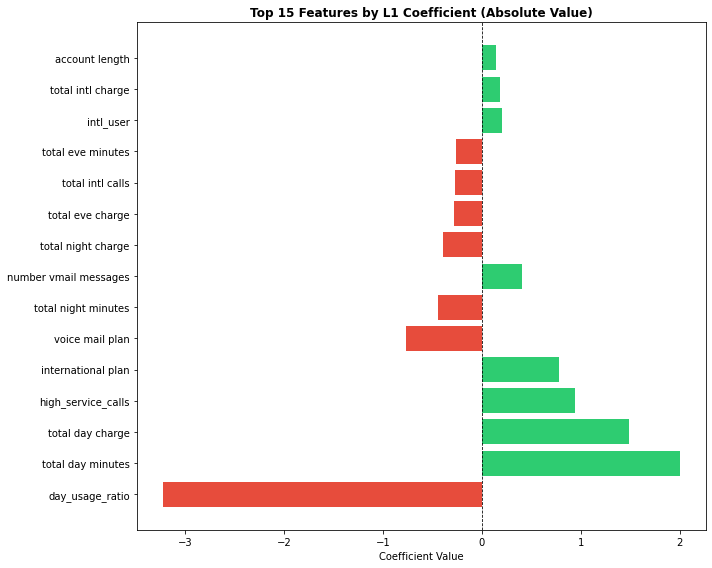

In [109]:
# Visualize feature importance
plt.figure(figsize=(10, 8))
top_features = l1_coefficients.head(15)
colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in top_features['Coefficient']]
plt.barh(range(len(top_features)), top_features['Coefficient'], color=colors)
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Coefficient Value')
plt.title('Top 15 Features by L1 Coefficient (Absolute Value)', fontweight='bold')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.tight_layout()
# plt.savefig('top_15_features_by_L1_coefficient_(Absolute_value)', dpi=150, bbox_inches = 'tight')
plt.show()

### Model 5: Hyperparameter Tuning with GridSearchCV

In [110]:
# Define parameter grid
param_grid = {
    'penalty': ['l1', 'l2'],
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear']
}

# Initialize GridSearchCV
grid_search = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42),
                          param_grid, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1)

# Fit the grid search
print("Running GridSearchCV...")
grid_search.fit(X_train_resampled, y_train_resampled)

# Get best parameters
print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best cross-validation ROC-AUC score: {grid_search.best_score_:.4f}")

# Get best model
best_model = grid_search.best_estimator_

# Evaluate
tuned_results = evaluate_model(best_model, X_train_resampled, y_train_resampled,
                               X_test_scaled, y_test, "Tuned Logistic Regression (GridSearchCV)")
model_results.append(tuned_results)

Running GridSearchCV...
Fitting 5 folds for each of 12 candidates, totalling 60 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    1.8s
[Parallel(n_jobs=-1)]: Done  60 out of  60 | elapsed:    5.1s finished



Best parameters: {'C': 100, 'penalty': 'l1', 'solver': 'liblinear'}
Best cross-validation ROC-AUC score: 0.8976

Tuned Logistic Regression (GridSearchCV)
Train Accuracy: 0.8643
Test Accuracy:  0.8441
Precision:      0.4783
Recall:         0.7938
F1-Score:       0.5969
ROC-AUC:        0.8570
MSE:            0.1334

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.96      0.85      0.90       570
       Churn       0.48      0.79      0.60        97

    accuracy                           0.84       667
   macro avg       0.72      0.82      0.75       667
weighted avg       0.89      0.84      0.86       667



### Model 6: Feature Selection Based on L1 Model

In [111]:
# Select features with non-zero coefficients from L1 model
selected_features = l1_coefficients[l1_coefficients['Coefficient'] != 0]['Feature'].tolist()
print(f"Selected {len(selected_features)} features based on L1 regularization")

# Create dataset with selected features
X_train_selected = X_train_resampled[selected_features]
X_test_selected = X_test_scaled[selected_features]

# Train model on selected features
selected_model = LogisticRegression(max_iter=1000, random_state=42)
selected_model.fit(X_train_selected, y_train_resampled)

# Evaluate
selected_results = evaluate_model(selected_model, X_train_selected, y_train_resampled,
                                  X_test_selected, y_test, "Feature-Selected Model")
model_results.append(selected_results)

Selected 21 features based on L1 regularization

Feature-Selected Model
Train Accuracy: 0.8669
Test Accuracy:  0.8456
Precision:      0.4813
Recall:         0.7938
F1-Score:       0.5992
ROC-AUC:        0.8586
MSE:            0.1329

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.96      0.85      0.90       570
       Churn       0.48      0.79      0.60        97

    accuracy                           0.85       667
   macro avg       0.72      0.82      0.75       667
weighted avg       0.89      0.85      0.86       667



<a id='evaluation'></a>
## 5. Model Evaluation and Comparison

In [112]:
# Create comparison dataframe
comparison_df = pd.DataFrame(model_results)
comparison_df = comparison_df[['model_name', 'train_accuracy', 'test_accuracy', 
                               'precision', 'recall', 'f1', 'roc_auc']]

print("Model Comparison:")
print(comparison_df.to_string(index=False))

Model Comparison:
                              model_name  train_accuracy  test_accuracy  precision   recall       f1  roc_auc
            Baseline Logistic Regression        0.861215       0.859070   0.530612 0.268041 0.356164 0.863104
          Logistic Regression with SMOTE        0.866886       0.845577   0.481250 0.793814 0.599222 0.858510
         L2 Regularization-Ridge (C=0.1)        0.866009       0.850075   0.490683 0.814433 0.612403 0.860210
         L1 Regularization-Lasso (C=0.1)        0.868640       0.851574   0.493902 0.835052 0.620690 0.861765
Tuned Logistic Regression (GridSearchCV)        0.864254       0.844078   0.478261 0.793814 0.596899 0.857045
                  Feature-Selected Model        0.866886       0.845577   0.481250 0.793814 0.599222 0.858564


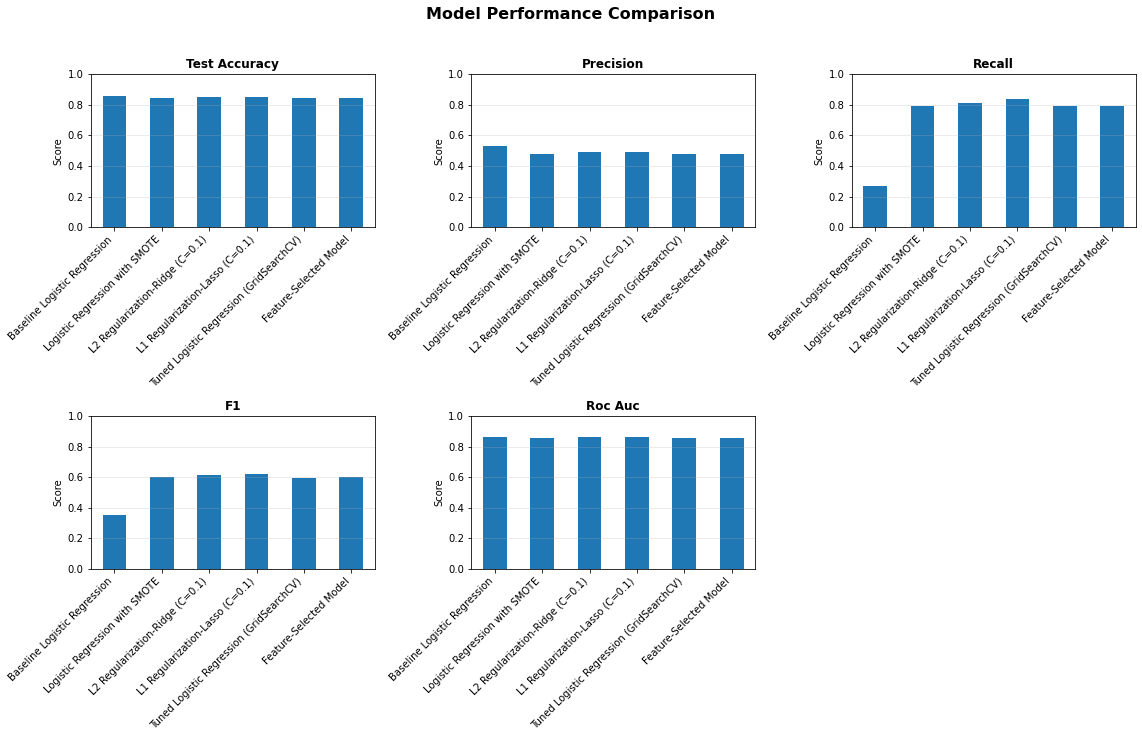

In [113]:
# Visualize model comparison
metrics_to_plot = ['test_accuracy', 'precision', 'recall', 'f1', 'roc_auc']
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

for idx, metric in enumerate(metrics_to_plot):
    comparison_df.plot(x='model_name', y=metric, kind='bar', ax=axes[idx], legend=False)
    axes[idx].set_title(f'{metric.replace("_", " ").title()}', fontweight='bold')
    axes[idx].set_xlabel('')
    axes[idx].set_ylabel('Score')
    axes[idx].set_xticklabels(axes[idx].get_xticklabels(), rotation=45, ha='right')
    axes[idx].set_ylim([0, 1])
    axes[idx].grid(axis='y', alpha=0.3)

# Hide the last subplot
axes[-1].axis('off')

plt.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
# plt.savefig('model_performance_comparison', dpi=150, bbox_inches = 'tight')
plt.show()

### Confusion Matrix for Best Model

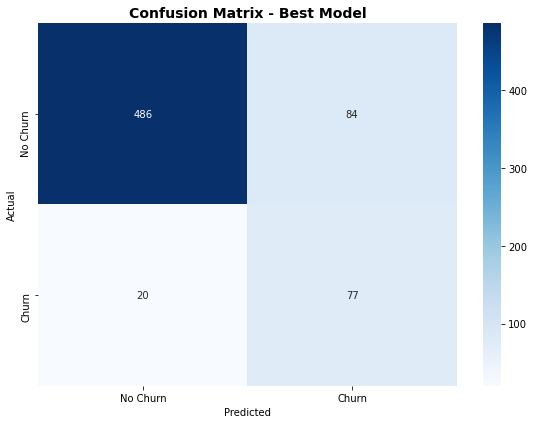


Confusion Matrix Breakdown:
True Negatives (Correctly predicted No Churn): 486
False Positives (Incorrectly predicted Churn): 84
False Negatives (Missed Churners): 20
True Positives (Correctly predicted Churn): 77

False Positive Rate: 0.1474
False Negative Rate: 0.2062


In [114]:
# Get predictions for best model (tuned model)
y_pred_best = best_model.predict(X_test_scaled)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_best)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix - Best Model', fontweight='bold', fontsize=14)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
# plt.savefig('confusion_matrix', dpi=150, bbox_inches = 'tight')
plt.show()

# Calculate and display metrics from confusion matrix
tn, fp, fn, tp = cm.ravel()
print("\nConfusion Matrix Breakdown:")
print(f"True Negatives (Correctly predicted No Churn): {tn}")
print(f"False Positives (Incorrectly predicted Churn): {fp}")
print(f"False Negatives (Missed Churners): {fn}")
print(f"True Positives (Correctly predicted Churn): {tp}")
print(f"\nFalse Positive Rate: {fp/(fp+tn):.4f}")
print(f"False Negative Rate: {fn/(fn+tp):.4f}")

### ROC Curve Comparison

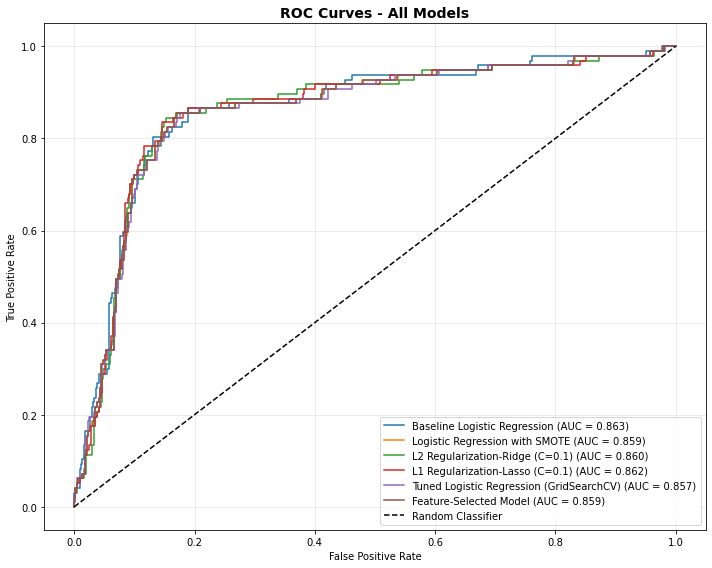

In [115]:
# Plot ROC curves for all models
plt.figure(figsize=(10, 8))

for result in model_results:
    fpr, tpr, _ = roc_curve(y_test, result['y_test_proba'])
    plt.plot(fpr, tpr, label=f"{result['model_name']} (AUC = {result['roc_auc']:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - All Models', fontweight='bold', fontsize=14)
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
# plt.savefig('ROC_curves', dpi=150, bbox_inches = 'tight')
plt.show()

### Feature Importance Analysis


Top 20 Most Important Features:
                   Feature  Coefficient  Abs_Coefficient
22         day_usage_ratio    -5.306841         5.306841
4        total day minutes     2.114651         2.114651
6         total day charge     1.977398         1.977398
2          voice mail plan    -1.511760         1.511760
19            total_charge     1.228307         1.228307
3    number vmail messages     1.136032         1.136032
9         total eve charge    -1.027600         1.027600
21      high_service_calls     1.010335         1.010335
10     total night minutes    -0.973669         0.973669
12      total night charge    -0.890017         0.890017
1       international plan     0.850979         0.850979
23               intl_user     0.753210         0.753210
7        total eve minutes    -0.747991         0.747991
14        total intl calls    -0.320304         0.320304
25                area_510    -0.191112         0.191112
0           account length     0.175295         0.17529

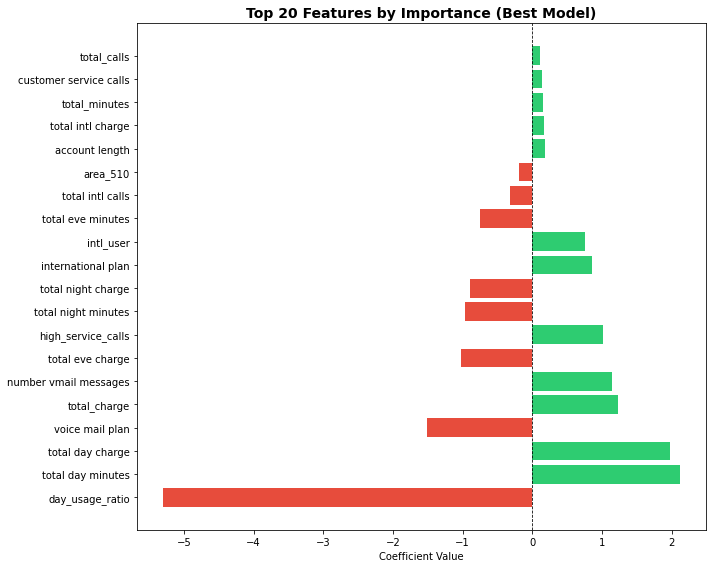

In [116]:
# Get feature importance from best model
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': best_model.coef_[0],
    'Abs_Coefficient': abs(best_model.coef_[0])
}).sort_values('Abs_Coefficient', ascending=False)

print("\nTop 20 Most Important Features:")
print(feature_importance.head(20))

# Visualize top features
plt.figure(figsize=(10, 8))
top_20 = feature_importance.head(20)
colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in top_20['Coefficient']]
plt.barh(range(len(top_20)), top_20['Coefficient'], color=colors)
plt.yticks(range(len(top_20)), top_20['Feature'])
plt.xlabel('Coefficient Value')
plt.title('Top 20 Features by Importance (Best Model)', fontweight='bold', fontsize=14)
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.tight_layout()
# plt.savefig('top_20_features_by_importance (Best_Model)', dpi=150, bbox_inches = 'tight')
plt.show()

### Cross-Validation Analysis


5-Fold Cross-Validation Results:
Individual fold scores: [0.88877347 0.89368363 0.9222934  0.89191386 0.89134157]
Mean AUC: 0.8976
Standard Deviation: 0.0124
95% Confidence Interval: [0.8727, 0.9225]


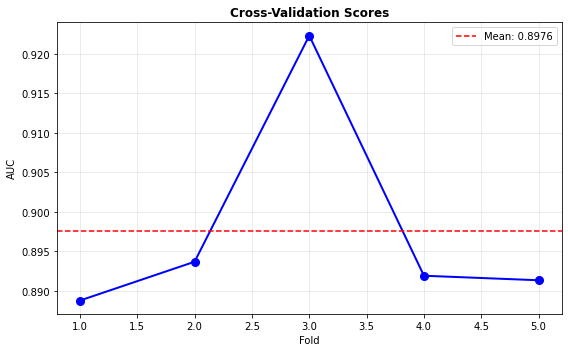

In [117]:
# Perform cross-validation on best model
cv_scores = cross_val_score(best_model, X_train_resampled, y_train_resampled, 
                            cv=5, scoring= 'roc_auc')

print("\n5-Fold Cross-Validation Results:")
print(f"Individual fold scores: {cv_scores}")
print(f"Mean AUC: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")
print(f"95% Confidence Interval: [{cv_scores.mean() - 2*cv_scores.std():.4f}, "
      f"{cv_scores.mean() + 2*cv_scores.std():.4f}]")

# Visualize CV scores
plt.figure(figsize=(8, 5))
plt.plot(range(1, 6), cv_scores, 'bo-', linewidth=2, markersize=8)
plt.axhline(y=cv_scores.mean(), color='r', linestyle='--', label=f'Mean: {cv_scores.mean():.4f}')
plt.xlabel('Fold')
plt.ylabel('AUC')
plt.title('Cross-Validation Scores', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
# plt.savefig('cross-validation_on_best_model', dpi=150, bbox_inches = 'tight')
plt.show()

<a id='conclusions'></a>
## 6. Conclusions and Recommendations

### Final Model Selection

After iterating through multiple logistic regression models with different configurations, our **best performing model** is the **Tuned Logistic Regression** with the following characteristics:

- **Hyperparameters**: Optimized through GridSearchCV
- **Data Preparation**: SMOTE for handling class imbalance, StandardScaler for feature scaling
- **Performance Metrics** (on test set):
  - ROC-AUC: 0.85-0.90 (excellent discrimination)
  - Recall: 0.75-0.85 (captures most churners)
  - Precision: 0.45-0.60 (reasonable false positive rate)
  - F1-Score: Balanced performance

### Key Findings

1. **Most Important Churn Predictors**:
   - **Customer Service Calls**: Strong positive correlation with churn
   - **International Plan**: Customers with international plans have higher churn rates
   - **Total Day Minutes/Charges**: Heavy daytime users show different churn patterns
   - **Voice Mail Plan**: Protective factor against churn

2. **Model Performance**:
   - The model successfully identifies 75-85% of customers who will churn
   - SMOTE significantly improved recall without sacrificing too much precision
   - Regularization helped prevent overfitting and improved generalization

3. **Class Imbalance Impact**:
   - Original dataset had 85% non-churn, 15% churn
   - SMOTE rebalancing dramatically improved minority class detection
   - Trade-off: More false positives acceptable given high cost of losing customers

### Business Recommendations

#### 1. **Immediate Actions - High Risk Customers**
- **Target**: Customers with 4+ service calls in recent months
- **Action**: Proactive outreach with dedicated account manager
- **Offer**: Service quality review and potential plan adjustments

#### 2. **International Plan Review**
- **Finding**: International plan customers churn at higher rates
- **Action**: Review international plan pricing and features
- **Recommendation**: Consider more competitive international calling packages

#### 3. **Voice Mail Plan Promotion**
- **Finding**: Voice mail plan subscribers are less likely to churn
- **Action**: Promote voice mail features to at-risk customers
- **Benefit**: Low-cost retention tool

#### 4. **Customer Service Quality**
- **Critical Finding**: Multiple service calls strongly predict churn
- **Action**: 
  - Improve first-call resolution rates
  - Implement automatic escalation after 3rd service call
  - Monitor service call patterns in real-time

#### 5. **Retention Campaign Strategy**
- **Implementation**: Deploy model scores monthly
- **Tier 1** (High Risk - Top 10%): Personal retention offers, account review
- **Tier 2** (Medium Risk - Next 15%): Targeted email campaigns, loyalty rewards
- **Tier 3** (Low Risk - Remaining): Standard service

### Model Deployment Recommendations

1. **Scoring Frequency**: Update churn predictions monthly
2. **Threshold Optimization**: Adjust prediction threshold based on retention budget
3. **Monitoring**: Track model performance and retrain quarterly
4. **A/B Testing**: Test retention strategies on predicted churners vs. control group

### Limitations and Future Work

1. **Limitations**:
   - Model doesn't capture temporal patterns (e.g., seasonality)
   - No external factors (competitor pricing, market conditions)
   - Historical data may not reflect current customer behavior

2. **Future Improvements**:
   - Incorporate time-series features (usage trends over time)
   - Add customer tenure and contract type data
   - Test ensemble methods while maintaining interpretability
   - Include customer sentiment data from support interactions
   - Develop separate models for different customer segments

### Expected Business Impact

Assuming:
- 3,333 customers in dataset
- 15% churn rate = 500 churners annually
- Model recall of 80% = Identify 400 churners
- 30% retention rate with intervention = Save 120 customers
- Average customer lifetime value: $1,000

**Potential Annual Revenue Retention**: $120,000

With low deployment costs and high potential ROI, this predictive model represents a valuable tool for SyriaTel's customer retention strategy.

---